In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from burgers_experiment_varying_picard_iters import get_all_data#, get_trj

/home/koehler/miniconda3/envs/emu-sup-paper-supplemental/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
configs = [
    {
        "network": network,
        "gamma_2": gamma_2,
        "delta_1": delta_1,
        "num_points": num_points,
        "ic_distribution": ic_distribution,
        "seed_init": seed_init,
        "seed_train": seed_train,
        "seed_test": seed_test,
        "seed_shuffle": seed_shuffle,
        "p_iters": p_iters,
    }
    for network in [
        # "Conv;34;10;relu",
        "UNet;12;2;relu",  # 27'193 params, 29 receptive field per direction
        # "Res;26;8;relu",  # 32'943 params, 16 receptive field per direction
        # "FNO;12;18;4;gelu",  # 32'527 params, inf receptive field per direction
        # "Dil;2;32;2;relu",  # 31'777 params, 20 receptive field per direction
        # "Trans;28;4;4;relu",  # 31'669 params, inf receptive field per direction
    ]
    for (gamma_2, delta_1, num_points, ic_distribution) in [
        (0.2, -8.0, 60, "fourier;1;False;True"),
    ]
    for p_iters in range(1, 5+1)
    for seed_init in range(30)
    for seed_train in range(100, 100+1)
    for seed_test in range(10_000, 10_000+1)
    for seed_shuffle in range(1_000_000, 1_000_000+1)
]

In [3]:
len(configs)

150

In [4]:
metrics, losses = get_all_data(configs)

100%|██████████| 150/150 [00:08<00:00, 18.40it/s]


In [5]:
metrics = pd.concat(metrics).reset_index(drop=True)
losses = pd.concat(losses).reset_index(drop=True)

In [6]:
# trj_dict_seed_0 = get_trj(configs[0])

In [7]:
# fig, ax = plt.subplots(1, 3, figsize=(5, 1))

# TRJ_IDX = 3 # Chosen because the IC is neatly centered in the domain

# ax[0].imshow(
#     trj_dict_seed_0["test_using_train_simulator"][TRJ_IDX][:, 0, :].T,
#     origin="lower",
#     cmap="RdBu_r",
#     aspect="auto",
#     vmin=-1,
#     vmax=1,
# )
# ax[1].imshow(
#     trj_dict_seed_0["test_neural"][TRJ_IDX][:, 0, :].T,
#     origin="lower",
#     cmap="RdBu_r",
#     aspect="auto",
#     vmin=-1,
#     vmax=1,
# )
# ax[2].imshow(
#     trj_dict_seed_0["test"][TRJ_IDX][:, 0, :].T,
#     origin="lower",
#     cmap="RdBu_r",
#     aspect="auto",
#     vmin=-1,
#     vmax=1,
# )

In [8]:
# facet = sns.relplot(
#     data=losses,
#     x="update_step",
#     y="loss",
#     kind="line",
#     hue="p_iters",
#     estimator="median",
#     errorbar=("pi", 50),
# )

# for ax in facet.axes.flat:
#     ax.set_yscale("log")

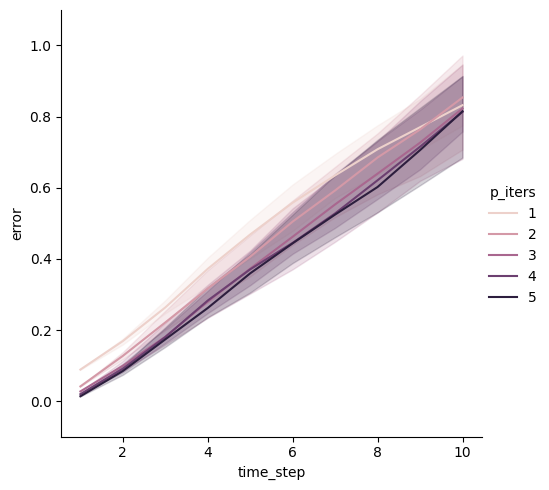

In [9]:
facet = sns.relplot(
    data=metrics.query("time_step <= 100"),
    x="time_step",
    y="error",
    hue="p_iters",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_ylim(-0.1, 1.1)

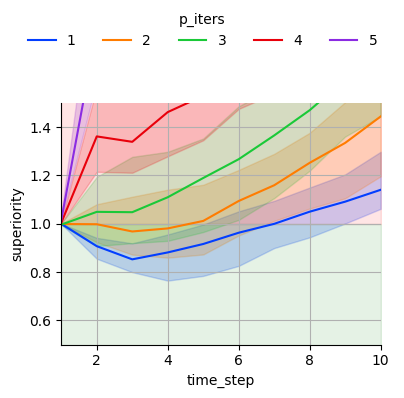

In [10]:
facet = sns.relplot(
    data=metrics.query("time_step <= 10"),
    x="time_step",
    y="superiority",
    hue="p_iters",
    # col="setting",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    palette="bright",
    height=4,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.5, 1.5)
    ax.fill_between(
        ax.lines[0].get_xdata(),
        0.0,
        1.0,
        color="green",
        alpha=0.1,
    )
    ax.fill_between(
        ax.lines[0].get_xdata(),
        1.0,
        2.0,
        color="red",
        alpha=0.1,
    )
    ax.set_xlim(1, 10)
    ax.grid()

facet.figure.subplots_adjust(top=0.75)

sns.move_legend(facet, "upper center", ncol=6)

In [15]:
pivoted_table = metrics.query("time_step <= 10 and p_iters <= 4").pivot(
    index=["p_iters", "seed_init", "seed_train", "seed_test", "seed_shuffle"],
    columns="time_step",
    values="superiority",
).groupby("p_iters").agg("median").round(2)

pivoted_table

time_step,1,2,3,4,5,6,7,8,9,10
p_iters,,,,,,,,,,
1,1.0,0.91,0.85,0.88,0.92,0.96,1.00,1.05,1.09,1.14
2,1.0,1.00,0.97,0.98,1.01,1.09,1.16,1.25,1.33,1.44
3,1.0,1.05,1.05,1.11,1.19,1.27,1.37,1.47,1.60,1.74
4,1.0,1.36,1.34,1.46,1.53,1.58,1.67,1.84,2.05,2.27


In [16]:
print(pivoted_table.to_markdown())

|   p_iters |   1 |    2 |    3 |    4 |    5 |    6 |    7 |    8 |    9 |   10 |
|----------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|         1 |   1 | 0.91 | 0.85 | 0.88 | 0.92 | 0.96 | 1    | 1.05 | 1.09 | 1.14 |
|         2 |   1 | 1    | 0.97 | 0.98 | 1.01 | 1.09 | 1.16 | 1.25 | 1.33 | 1.44 |
|         3 |   1 | 1.05 | 1.05 | 1.11 | 1.19 | 1.27 | 1.37 | 1.47 | 1.6  | 1.74 |
|         4 |   1 | 1.36 | 1.34 | 1.46 | 1.53 | 1.58 | 1.67 | 1.84 | 2.05 | 2.27 |
